In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import GridSearchCV
import joblib #TO SAVE AND load lodel

In [4]:
iris = load_iris()

In [5]:
from os import name
X= pd.DataFrame(iris.data, columns=iris.feature_names)
y=pd.Series(iris.target, name='target')

In [6]:
X

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [7]:
print("Shape:", X.shape)
print("Class distribution:\n", y.value_counts().sort_index())
print("Feature head:\n", X.head())

Shape: (150, 4)
Class distribution:
 target
0    50
1    50
2    50
Name: count, dtype: int64
Feature head:
    sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2


Note: Iris has 3 classes; decision trees handle multiclass naturally.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
print("Train/Test shapes:", X_train.shape, X_test.shape)

Train/Test shapes: (112, 4) (38, 4)


In [9]:
clf = DecisionTreeClassifier(
    criterion='gini',          # 'gini' or 'entropy'
    splitter='best',           # how to choose split ('best' or 'random')
    max_depth=None,            # None = expand until leaves are pure or min_samples_leaf
    min_samples_split=2,
    min_samples_leaf=1,
    max_features=None,
    class_weight=None,
    random_state=42
)

In [10]:
print("Initial params:", clf.get_params())

Initial params: {'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': 42, 'splitter': 'best'}


In [11]:
clf.fit(X_train, y_train)
print("Training accuracy:", clf.score(X_train, y_train))

Training accuracy: 1.0


In [12]:
y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)  # probability for each class

print("Predictions (first 10):", y_pred[:10])
print("Predicted probabilities (first 3 rows):\n", y_proba[:3])

Predictions (first 10): [0 1 1 1 0 1 1 2 2 2]
Predicted probabilities (first 3 rows):
 [[1. 0. 0.]
 [0. 1. 0.]
 [0. 1. 0.]]


In [13]:
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Test Accuracy: 0.8947368421052632

Confusion Matrix:
 [[12  0  0]
 [ 0 12  1]
 [ 0  3 10]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       0.80      0.92      0.86        13
           2       0.91      0.77      0.83        13

    accuracy                           0.89        38
   macro avg       0.90      0.90      0.90        38
weighted avg       0.90      0.89      0.89        38



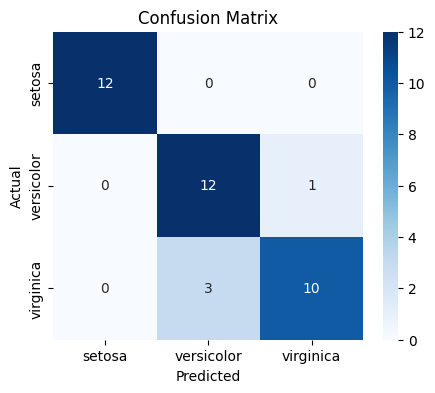

In [14]:
import seaborn as sns
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [15]:
# Inspect feature importances and tree internals

fi = pd.Series(clf.feature_importances_, index=X.columns).sort_values(ascending=False)
print("Feature importances:\n", fi)

# Access raw tree object (useful for advanced inspection)
sk_tree = clf.tree_
print("Number of nodes in the tree:", sk_tree.node_count)
print("Max depth:", clf.get_depth())

Feature importances:
 petal length (cm)    0.919887
petal width (cm)     0.046629
sepal width (cm)     0.020091
sepal length (cm)    0.013394
dtype: float64
Number of nodes in the tree: 17
Max depth: 6



Decision rules (text):
 |--- petal length (cm) <= 2.45
|   |--- class: 0
|--- petal length (cm) >  2.45
|   |--- petal length (cm) <= 4.85
|   |   |--- petal width (cm) <= 1.65
|   |   |   |--- class: 1
|   |   |--- petal width (cm) >  1.65
|   |   |   |--- sepal length (cm) <= 6.05
|   |   |   |   |--- class: 1
|   |   |   |--- sepal length (cm) >  6.05
|   |   |   |   |--- class: 2
|   |--- petal length (cm) >  4.85
|   |   |--- petal width (cm) <= 1.70
|   |   |   |--- petal length (cm) <= 4.95
|   |   |   |   |--- class: 1
|   |   |   |--- petal length (cm) >  4.95
|   |   |   |   |--- sepal width (cm) <= 2.75
|   |   |   |   |   |--- sepal width (cm) <= 2.45
|   |   |   |   |   |   |--- class: 2
|   |   |   |   |   |--- sepal width (cm) >  2.45
|   |   |   |   |   |   |--- class: 1
|   |   |   |   |--- sepal width (cm) >  2.75
|   |   |   |   |   |--- class: 2
|   |   |--- petal width (cm) >  1.70
|   |   |   |--- class: 2



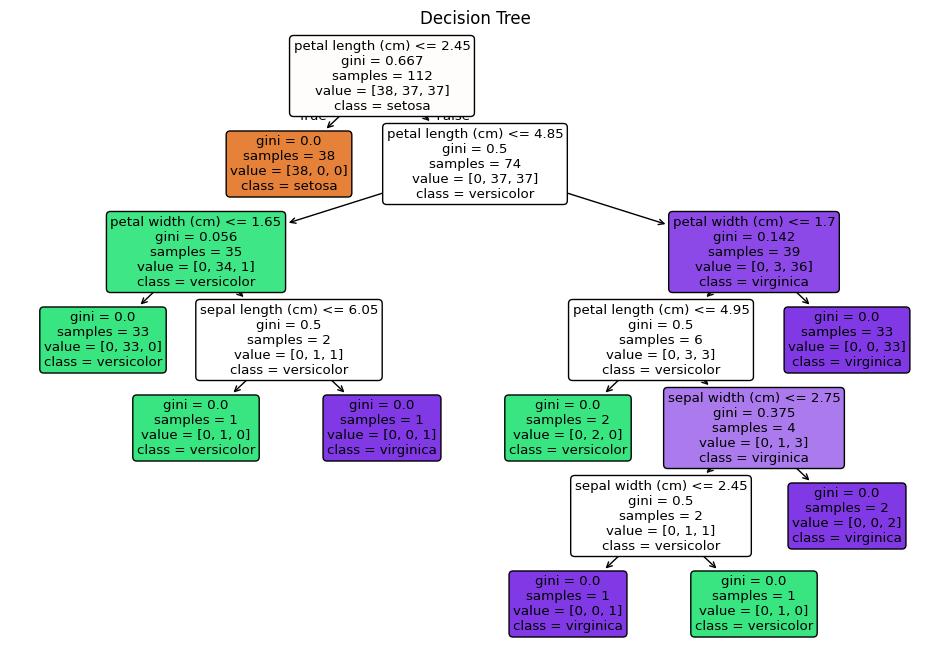

In [16]:
# text representation
r = export_text(clf, feature_names=list(X.columns))
print("\nDecision rules (text):\n", r)

# plot (uses matplotlib)
plt.figure(figsize=(12,8))
plot_tree(clf, feature_names=X.columns, class_names=iris.target_names, filled=True, rounded=True)
plt.title("Decision Tree")
plt.show()

In [17]:
# apply(X) returns leaf index for each sample
leaf_indices = clf.apply(X_test)
print("Leaf indices for first 10 test samples:", leaf_indices[:10])

# decision_path returns a sparse matrix indicating which nodes were visited
node_indicator = clf.decision_path(X_test)
sample_id = 0
node_index = node_indicator.indices[node_indicator.indptr[sample_id]:node_indicator.indptr[sample_id+1]]
print(f"Nodes visited by test sample {sample_id}:", node_index)

Leaf indices for first 10 test samples: [ 1  4  4  4  1  4 14 16 16 16]
Nodes visited by test sample 0: [0 1]


In [18]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(clf, X, y, cv=5, scoring='accuracy')
print("5-fold CV accuracy scores:", cv_scores)
print("Mean CV accuracy:", cv_scores.mean())

5-fold CV accuracy scores: [0.96666667 0.96666667 0.9        0.93333333 1.        ]
Mean CV accuracy: 0.9533333333333334


In [29]:
print("CV accuracy mean:", cv_scores.mean())
print("CV accuracy std deviation:", cv_scores.std())

CV accuracy mean: 0.9533333333333334
CV accuracy std deviation: 0.03399346342395189


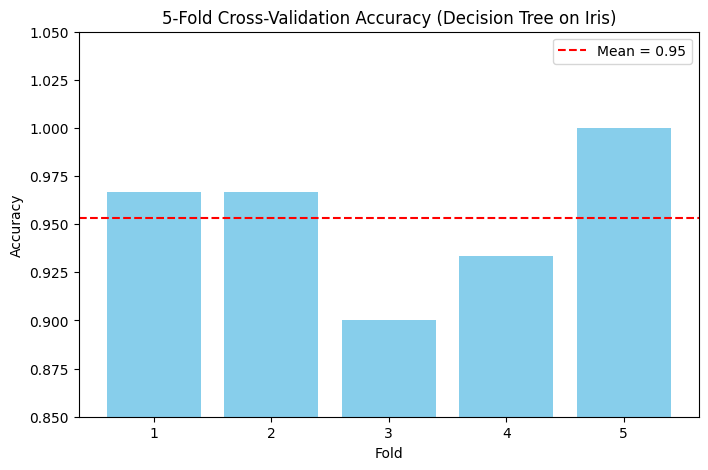

In [31]:
# Bar plot of fold-wise accuracies
plt.figure(figsize=(8,5))
plt.bar(range(1, len(cv_scores)+1), cv_scores, color='skyblue')
plt.axhline(y=cv_scores.mean(), color='red', linestyle='--', label=f"Mean = {cv_scores.mean():.2f}")
plt.ylim(0.85, 1.05)
plt.xticks(range(1, len(cv_scores)+1))
plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.title("5-Fold Cross-Validation Accuracy (Decision Tree on Iris)")
plt.legend()
plt.show()

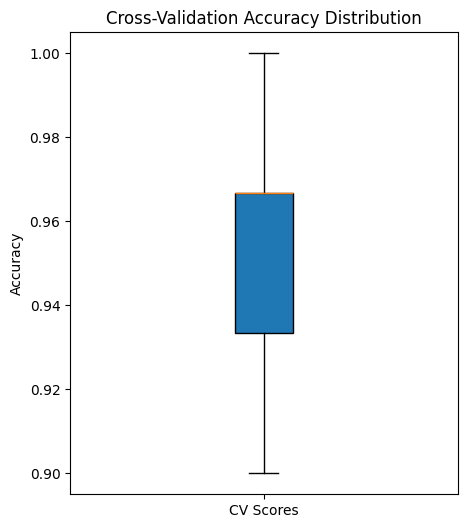

In [32]:
# Boxplot for distribution of CV scores
plt.figure(figsize=(5,6))
plt.boxplot(cv_scores, vert=True, patch_artist=True)
plt.xticks([1], ["CV Scores"])
plt.ylabel("Accuracy")
plt.title("Cross-Validation Accuracy Distribution")
plt.show()

In [30]:
# Cost-complexity pruning path (ccp_alpha) and visualize effect
# -------------------------
path = clf.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities
print("Found %d alphas" % len(ccp_alphas))


Found 7 alphas


In [20]:
# Train trees for each alpha and record validation accuracy (on a held-out part of X_train)
clfs = []
for ccp_alpha in ccp_alphas:
    dt = DecisionTreeClassifier(random_state=42, ccp_alpha=ccp_alpha)
    dt.fit(X_train, y_train)
    clfs.append(dt)

# Remove the last trivial tree
clfs = clfs[:-1]
ccp_alphas = ccp_alphas[:-1]

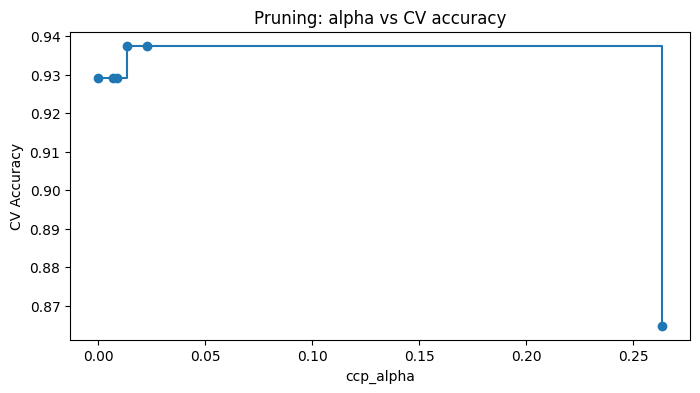

In [21]:
# compute validation accuracy for each pruned tree using cross_val_score
alpha_scores = [cross_val_score(dt, X_train, y_train, cv=5).mean() for dt in clfs]

plt.figure(figsize=(8,4))
plt.plot(ccp_alphas, alpha_scores, marker='o', drawstyle="steps-post")
plt.xlabel("ccp_alpha")
plt.ylabel("CV Accuracy")
plt.title("Pruning: alpha vs CV accuracy")
plt.show()


In [22]:
# choose best alpha and refit final model
best_alpha = ccp_alphas[np.argmax(alpha_scores)]
print("Best ccp_alpha:", best_alpha)
pruned_clf = DecisionTreeClassifier(random_state=42, ccp_alpha=best_alpha)
pruned_clf.fit(X_train, y_train)
print("Pruned test accuracy:", pruned_clf.score(X_test, y_test))

Best ccp_alpha: 0.013392857142857142
Pruned test accuracy: 0.8947368421052632


In [23]:
# Hyperparameter tuning with GridSearchCV (example)
# -------------------------
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 2, 3, 4, 5],
    'min_samples_split': [2, 4, 6],
    'min_samples_leaf': [1, 2, 3]
}
gs = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=5, scoring='accuracy', n_jobs=-1)
gs.fit(X_train, y_train)
print("Best params from GridSearch:", gs.best_params_)
best_dt = gs.best_estimator_
print("Test accuracy (best estimator):", best_dt.score(X_test, y_test))

Best params from GridSearch: {'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 4}
Test accuracy (best estimator): 0.8947368421052632


In [24]:
# 13) Save / load model
# -------------------------
joblib.dump(best_dt, "best_decision_tree.joblib")
loaded = joblib.load("best_decision_tree.joblib")
print("Loaded model test score:", loaded.score(X_test, y_test))

Loaded model test score: 0.8947368421052632


In [25]:
import joblib

# Load trained model
loaded = joblib.load("best_decision_tree.joblib")

In [26]:
# Example new flower
new_sample = pd.DataFrame([[5.1, 3.5, 1.4, 0.2]],
                          columns=["sepal length (cm)", "sepal width (cm)",
                                   "petal length (cm)", "petal width (cm)"])
print(new_sample)

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2


In [27]:
prediction = loaded.predict(new_sample)
probabilities = loaded.predict_proba(new_sample)

print("Predicted class (numeric):", prediction[0])
print("Class probabilities:", probabilities)

Predicted class (numeric): 0
Class probabilities: [[1. 0. 0.]]


In [28]:
from sklearn.datasets import load_iris
iris = load_iris()

print("Predicted flower species:", iris.target_names[prediction][0])

Predicted flower species: setosa
